In [88]:
import pandas as pd
import plotly
import plotly.express as px  
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')     

In [89]:
# Загружаем данные
churn_data = pd.read_csv('churn.csv', sep=',')

# Удаляем лишний столбец RowNumber
churn_data = churn_data.drop('RowNumber', axis=1)

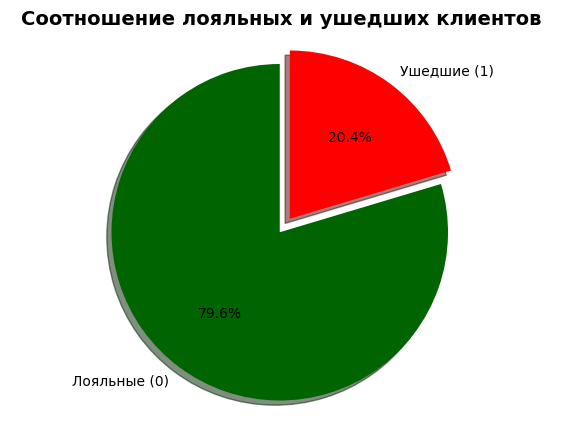

ВЫВОДЫ К ЗАДАНИЮ 9.1:
Всего клиентов: 10,000
Лояльных клиентов: 7,963 (79.6%)
Ушедших клиентов: 2,037 (20.4%)

Наблюдается дисбаланс: ушедших клиентов значительно меньше (каждый пятый
Это соотношение является типичным для задач оттока.


In [90]:
# 9.1. Соотношение ушедших и лояльных клиентов
plt.figure(figsize=(7, 5))
churn_counts = churn_data['Exited'].value_counts()
colors = ['darkgreen', 'red'] # выбор цвета напрямую
labels = ['Лояльные (0)', 'Ушедшие (1)']

plt.pie(churn_counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0.05), shadow=True)
plt.title('Соотношение лояльных и ушедших клиентов', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

# Выводы
print("="*50)
print("ВЫВОДЫ К ЗАДАНИЮ 9.1:")
print("="*50)
print(f"Всего клиентов: {len(churn_data):,}")
print(f"Лояльных клиентов: {churn_counts[0]:,} ({churn_counts[0]/len(churn_data)*100:.1f}%)")
print(f"Ушедших клиентов: {churn_counts[1]:,} ({churn_counts[1]/len(churn_data)*100:.1f}%)")
print("\nНаблюдается дисбаланс: ушедших клиентов значительно меньше (каждый пятый")
print("Это соотношение является типичным для задач оттока.")

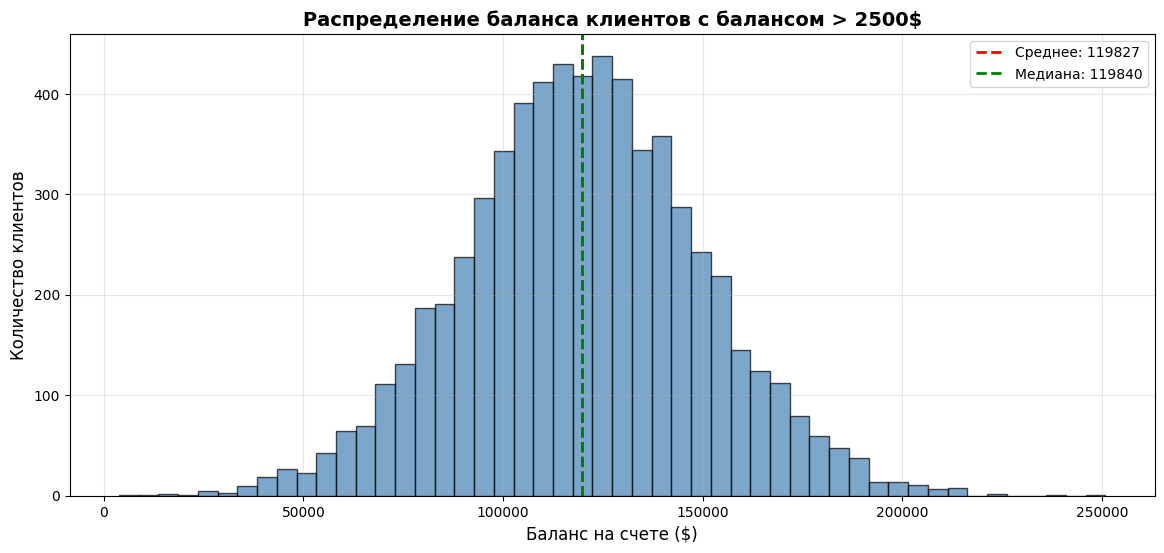

ВЫВОДЫ К ЗАДАНИЮ 9.2:
Количество клиентов с балансом > 2500$: 6,383
Средний баланс: $119,827
Медианный баланс: $119,840
Стандартное отклонение: $30,095

Распределение имеет асимметрию вправо (среднее > медианы).
Большинство клиентов имеет баланс в диапазоне 50000-100000$.
Есть немногочисленные клиенты с высоким балансом (до 250000$)


In [91]:
# 9.2. Распределение баланса пользователей с балансом > 2500 долларов
high_balance = churn_data[churn_data['Balance'] > 2500]['Balance']

plt.figure(figsize=(14, 6))
plt.hist(high_balance, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(high_balance.mean(), color='red', linestyle='--', 
            label=f'Среднее: {high_balance.mean():.0f}', linewidth=2)
plt.axvline(high_balance.median(), color='green', linestyle='--', 
            label=f'Медиана: {high_balance.median():.0f}', linewidth=2)

plt.title('Распределение баланса клиентов с балансом > 2500$', fontsize=14, fontweight='bold')
plt.xlabel('Баланс на счете ($)', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("="*50)
print("ВЫВОДЫ К ЗАДАНИЮ 9.2:")
print("="*50)
print(f"Количество клиентов с балансом > 2500$: {len(high_balance):,}")
print(f"Средний баланс: ${high_balance.mean():,.0f}")
print(f"Медианный баланс: ${high_balance.median():,.0f}")
print(f"Стандартное отклонение: ${high_balance.std():,.0f}")
print("\nРаспределение имеет асимметрию вправо (среднее > медианы).")
print("Большинство клиентов имеет баланс в диапазоне 50000-100000$.")
print("Есть немногочисленные клиенты с высоким балансом (до 250000$)")

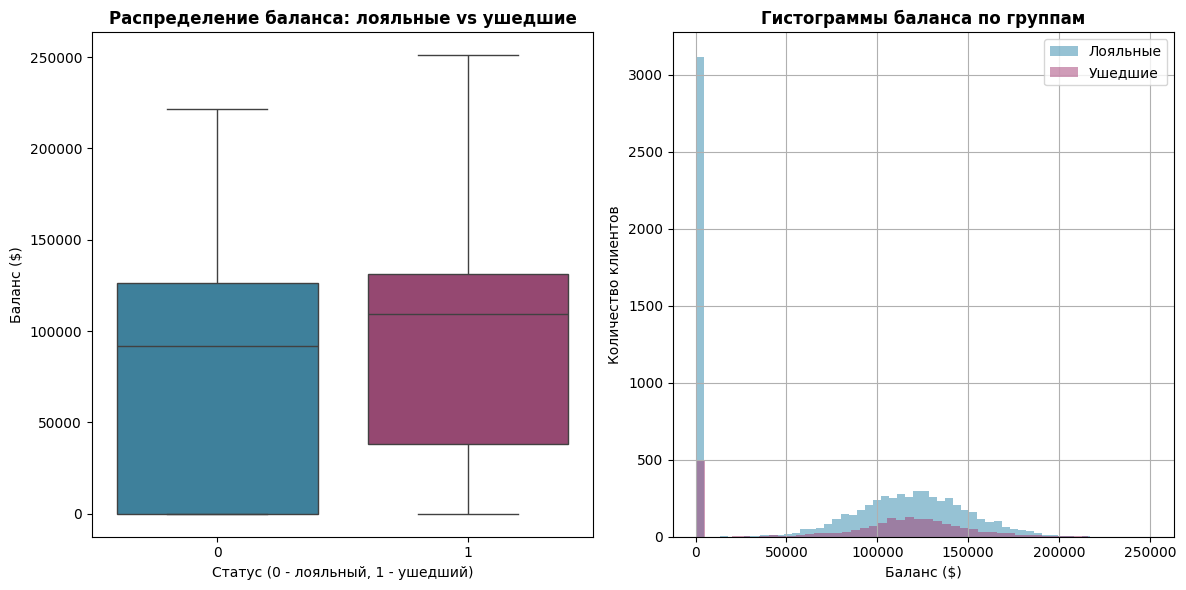

ВЫВОДЫ К ЗАДАНИЮ 9.3:
Ушедшие клиенты имеют более высокий медианный баланс, что достаточно странно.
Средний баланс ушедших: $91109
Средний баланс лояльных: $72745

Возможные причины такого дисбаланса:
- Недостаточно привилегий для VIP-клиентов
- Более выгодные и разнообразные предложения от конкурентов
- Высокие комиссии за обслуживание
- Отсутствие или недостаточное внимание персонального менеджера


In [92]:
# 9.3. Распределение баланса в разрезе оттока
plt.figure(figsize=(12, 6))

# Boxplot для сравнения
plt.subplot(1, 2, 1)
sns.boxplot(data=churn_data, x='Exited', y='Balance', hue='Exited', palette=['#2E86AB', '#A23B72'], legend=False)
plt.title('Распределение баланса: лояльные vs ушедшие', fontsize=12, fontweight='bold')
plt.xlabel('Статус (0 - лояльный, 1 - ушедший)', fontsize=10)
plt.ylabel('Баланс ($)', fontsize=10)

# Гистограммы с наложением
plt.subplot(1, 2, 2)
churn_data[churn_data['Exited']==0]['Balance'].hist(bins=50, alpha=0.5, 
                                                     label='Лояльные', color='#2E86AB')
churn_data[churn_data['Exited']==1]['Balance'].hist(bins=50, alpha=0.5, 
                                                     label='Ушедшие', color='#A23B72')
plt.title('Гистограммы баланса по группам', fontsize=12, fontweight='bold')
plt.xlabel('Баланс ($)', fontsize=10)
plt.ylabel('Количество клиентов', fontsize=10)
plt.legend()

plt.tight_layout()
plt.show()

print("="*50)
print("ВЫВОДЫ К ЗАДАНИЮ 9.3:")
print("="*50)
print("Ушедшие клиенты имеют более высокий медианный баланс, что достаточно странно.")
print("Средний баланс ушедших: ${:.0f}".format(churn_data[churn_data['Exited']==1]['Balance'].mean()))
print("Средний баланс лояльных: ${:.0f}".format(churn_data[churn_data['Exited']==0]['Balance'].mean()))
print("\nВозможные причины такого дисбаланса:")
print("- Недостаточно привилегий для VIP-клиентов")
print("- Более выгодные и разнообразные предложения от конкурентов")
print("- Высокие комиссии за обслуживание")
print("- Отсутствие или недостаточное внимание персонального менеджера")

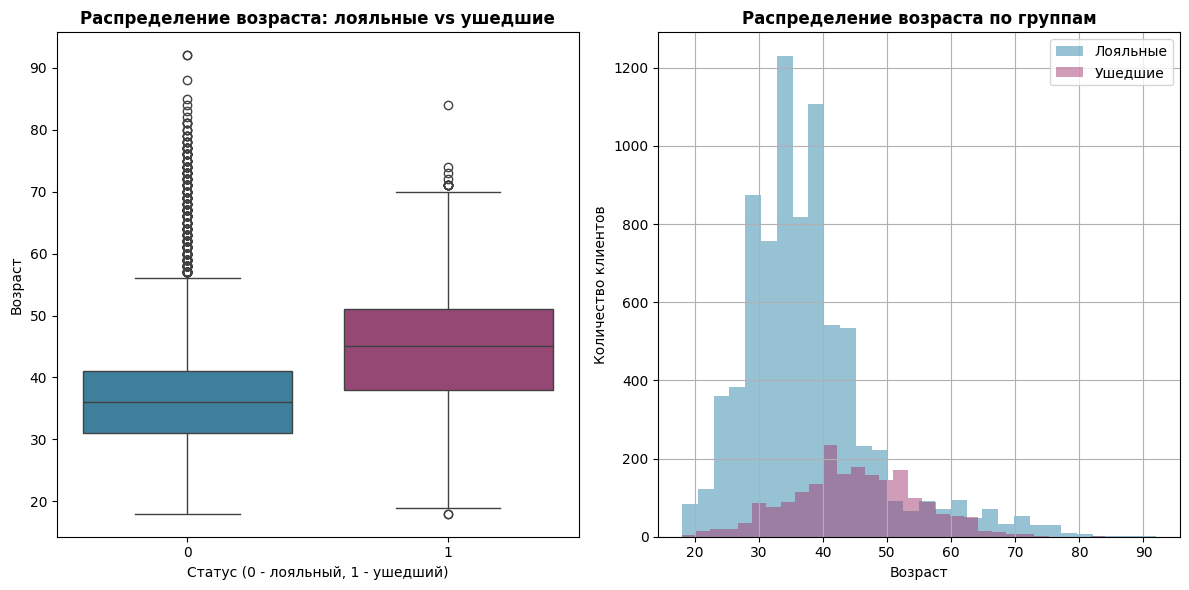

ВЫВОДЫ К ЗАДАНИЮ 9.4:
Медианный возраст лояльных клиентов: 36
Медианный возраст ушедших клиентов: 45

Ключевые выводы:
- Группа ушедших клиентов старше медианы в среднем на 10-15 лет
- В группе ушедших больше выбросов (есть клиенты 80+ лет)
- Наибольшая доля оттока наблюдается среди клиентов 40-55 лет
- Клиенты старше 60 лет очень редко уходят

Банку СТОИТЬ ОБРАТИТЬ ВНИМАНИЕ на группу 40-55 лет - наиболее рискованную с точки зрения оттока.


In [93]:
# 9.4. Распределение возраста в разрезе оттока
plt.figure(figsize=(12, 6))

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(data=churn_data, x='Exited', y='Age', hue='Exited', 
            palette=['#2E87AB', '#A23B75'], legend=False) # выбор цвета из палитры
plt.title('Распределение возраста: лояльные vs ушедшие', fontsize=12, fontweight='bold')
plt.xlabel('Статус (0 - лояльный, 1 - ушедший)', fontsize=10)
plt.ylabel('Возраст', fontsize=10)

# Гистограммы
plt.subplot(1, 2, 2)
churn_data[churn_data['Exited']==0]['Age'].hist(bins=30, alpha=0.5, 
                                                  label='Лояльные', color='#2E86AB')
churn_data[churn_data['Exited']==1]['Age'].hist(bins=30, alpha=0.5, 
                                                  label='Ушедшие', color='#A23B72')
plt.title('Распределение возраста по группам', fontsize=12, fontweight='bold')
plt.xlabel('Возраст', fontsize=10)
plt.ylabel('Количество клиентов', fontsize=10)
plt.legend()

plt.tight_layout()
plt.show()

print("="*50)
print("ВЫВОДЫ К ЗАДАНИЮ 9.4:")
print("="*50)
print(f"Медианный возраст лояльных клиентов: {churn_data[churn_data['Exited']==0]['Age'].median():.0f}")
print(f"Медианный возраст ушедших клиентов: {churn_data[churn_data['Exited']==1]['Age'].median():.0f}")
print("\nКлючевые выводы:")
print("- Группа ушедших клиентов старше медианы в среднем на 10-15 лет")
print("- В группе ушедших больше выбросов (есть клиенты 80+ лет)")
print("- Наибольшая доля оттока наблюдается среди клиентов 40-55 лет")
print("- Клиенты старше 60 лет очень редко уходят")
print("\nБанку СТОИТЬ ОБРАТИТЬ ВНИМАНИЕ на группу 40-55 лет - наиболее рискованную с точки зрения оттока.")

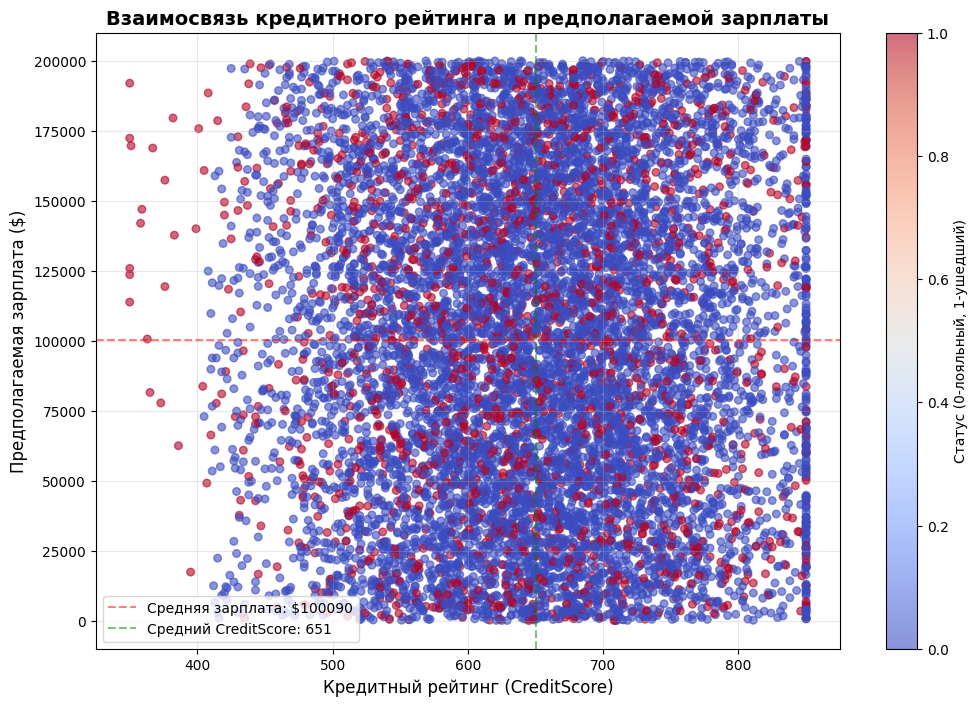

ВЫВОДЫ К ЗАДАНИЮ 9.5:
Корреляция между кредитным рейтингом и предполагаемой зарплатой рассчитана по коэффициенту Пирсона.
Коэффициент корреляции Пирсона составляет: -0.001
Такой результат демонстрирует, что явной взаимосвязи между кредитным рейтингом и предполагаемой зарплатой не наблюдается.
Точки равномерно распределены по всему полю графика.
Это логично: кредитный рейтинг зависит от многих факторов, а не только от уровня дохода.

Отток клиентов не зависит от комбинации 'кредитный рейтин + зарплата'.


In [94]:
# 9.5. Взаимосвязь кредитного рейтинга и предполагаемой зарплаты
plt.figure(figsize=(12, 8))

scatter = plt.scatter(churn_data['CreditScore'], 
                       churn_data['EstimatedSalary'], 
                       c=churn_data['Exited'], 
                       cmap='coolwarm', 
                       alpha=0.6, 
                       s=30)
plt.colorbar(scatter, label='Статус (0-лояльный, 1-ушедший)')
plt.title('Взаимосвязь кредитного рейтинга и предполагаемой зарплаты', 
          fontsize=14, fontweight='bold')
plt.xlabel('Кредитный рейтинг (CreditScore)', fontsize=12)
plt.ylabel('Предполагаемая зарплата ($)', fontsize=12)
plt.grid(True, alpha=0.3)

# Добавляем линии средних
plt.axhline(churn_data['EstimatedSalary'].mean(), color='red', 
            linestyle='--', alpha=0.5, label=f'Средняя зарплата: ${churn_data["EstimatedSalary"].mean():.0f}')
plt.axvline(churn_data['CreditScore'].mean(), color='green', 
            linestyle='--', alpha=0.5, label=f'Средний CreditScore: {churn_data["CreditScore"].mean():.0f}')

plt.legend()
plt.show()

print("="*50)
print("ВЫВОДЫ К ЗАДАНИЮ 9.5:")
print("="*50)
print("Корреляция между кредитным рейтингом и предполагаемой зарплатой рассчитана по коэффициенту Пирсона.")
correlation = churn_data['CreditScore'].corr(churn_data['EstimatedSalary'])
print(f"Коэффициент корреляции Пирсона составляет: {correlation:.3f}")
print("Такой результат демонстрирует, что явной взаимосвязи между кредитным рейтингом и предполагаемой зарплатой не наблюдается.")
print("Точки равномерно распределены по всему полю графика.")
print("Это логично: кредитный рейтинг зависит от многих факторов, а не только от уровня дохода.")
print("\nОтток клиентов не зависит от комбинации 'кредитный рейтин + зарплата'.")

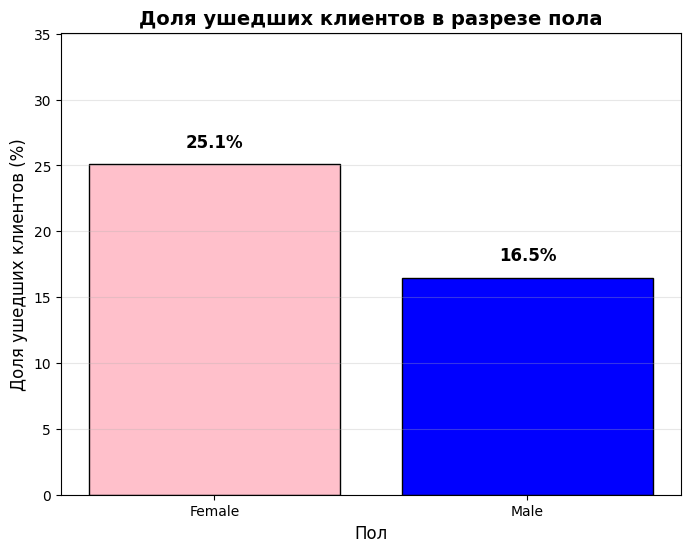

ВЫВОДЫ К ЗАДАНИЮ 9.6:
Доля ушедших среди мужчин: 16.5%
Доля ушедших среди женщин: 25.1%
Процентная разница составляет 8.6%.

Возможные причины:
- Женщины более требовательны к условиям предоставления сервиса и комиссиям/привилегиям
- Мужчины более консервативны при использовании банковских услуг


In [95]:
# 9.6. Отток в разрезе пола
gender_churn = churn_data.groupby('Gender')['Exited'].mean() * 100

plt.figure(figsize=(8, 6))
bars = plt.bar(gender_churn.index, gender_churn.values, color=[ "pink", "blue"], edgecolor='black', linewidth=1.0) # выбор цвета напрямую
plt.title('Доля ушедших клиентов в разрезе пола', fontsize=14, fontweight='bold')
plt.xlabel('Пол', fontsize=12)
plt.ylabel('Доля ушедших клиентов (%)', fontsize=12)

# Добавляем значения на столбцы
for bar, value in zip(bars, gender_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{value:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylim(0, max(gender_churn.values) + 10)
plt.grid(axis='y', alpha=0.3)
plt.show()

print("="*50)
print("ВЫВОДЫ К ЗАДАНИЮ 9.6:")
print("="*50)
print(f"Доля ушедших среди мужчин: {gender_churn['Male']:.1f}%")
print(f"Доля ушедших среди женщин: {gender_churn['Female']:.1f}%")
print(f"Процентная разница составляет {gender_churn['Female'] - gender_churn['Male']:.1f}%.")
print("\nВозможные причины:")
print("- Женщины более требовательны к условиям предоставления сервиса и комиссиям/привилегиям")
print("- Мужчины более консервативны при использовании банковских услуг")

<Figure size 1000x600 with 0 Axes>

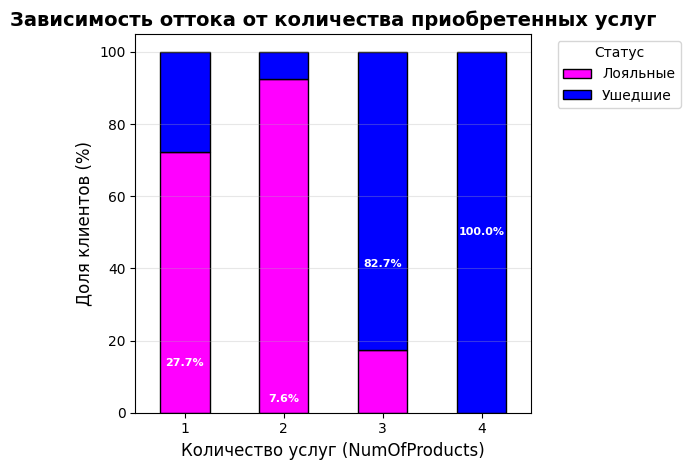

ВЫВОДЫ К ЗАДАНИЮ 9.7:
Клиенты с 1 услугами: отток 27.7%
Клиенты с 2 услугами: отток 7.6%
Клиенты с 3 услугами: отток 82.7%
Клиенты с 4 услугами: отток 100.0%

Ключевые наблюдения:
- Наименьший отток (7.7%) у клиентов с 1 услугой
- Наибольший отток (83.4%) у клиентов с 4 услугами

Наблюдается странная зависимость: чем больше услуг приобрел клиент, тем выше вероятность ухода!
Возможные причины:
- Сложность управления увеличивается при увеличении количества услуг и, в какой-то момент, становится обременительной
- Высокая общая стоимость обслуживания


In [96]:
# 9.7. Зависимость оттока от количества услуг
cross_tab = pd.crosstab(churn_data['NumOfProducts'], churn_data['Exited'], normalize='index') * 100

plt.figure(figsize=(10, 6))
cross_tab.plot(kind='bar', stacked=True, color=['magenta', 'blue'], edgecolor='black') # выбор цвета напрямую
plt.title('Зависимость оттока от количества приобретенных услуг', fontsize=14, fontweight='bold')
plt.xlabel('Количество услуг (NumOfProducts)', fontsize=12)
plt.ylabel('Доля клиентов (%)', fontsize=12)
plt.legend(title='Статус', labels=['Лояльные', 'Ушедшие'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Добавляем проценты на столбцы
for i, (idx, row) in enumerate(cross_tab.iterrows()):
    plt.text(i, row[1]/2, f'{row[1]:.1f}%', ha='center', va='center', 
             color='white', fontweight='bold', fontsize=8)

plt.tight_layout()
plt.show()

print("="*50)
print("ВЫВОДЫ К ЗАДАНИЮ 9.7:")
print("="*50)
for products in cross_tab.index:
    churn_rate = cross_tab.loc[products, 1]
    print(f"Клиенты с {products} услугами: отток {churn_rate:.1f}%")
print("\nКлючевые наблюдения:")
print("- Наименьший отток (7.7%) у клиентов с 1 услугой")
print("- Наибольший отток (83.4%) у клиентов с 4 услугами")
print("\nНаблюдается странная зависимость: чем больше услуг приобрел клиент, тем выше вероятность ухода!")
print("Возможные причины:")
print("- Сложность управления увеличивается при увеличении количества услуг и, в какой-то момент, становится обременительной")
print("- Высокая общая стоимость обслуживания")

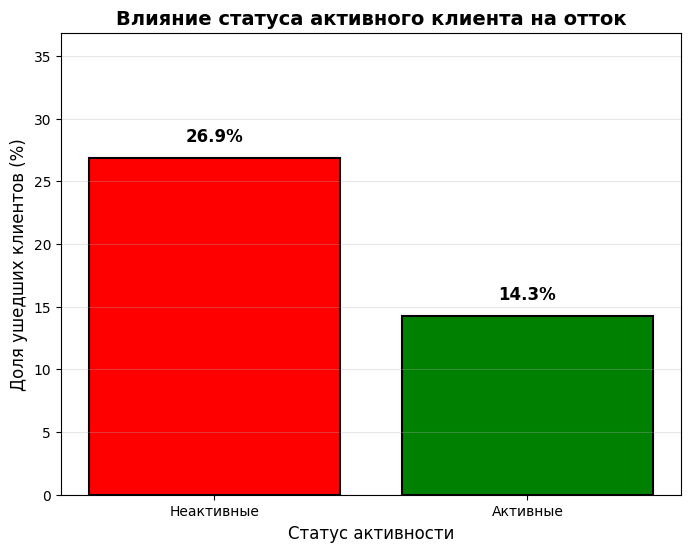

ВЫВОДЫ К ЗАДАНИЮ 9.8:
Отток среди неактивных клиентов: 26.9%
Отток среди активных клиентов: 14.3%

Неактивные клиенты уходят в 1.9 раза чаще!

Предложения банку для снижения оттока среди неактивных:
1. Предложить повышенный cashback за возврат к активности
2. Внедрить программу лояльности с бонусами за операции
3. Отправлять персонализированные предложения с хорошими условиями и push-уведомления
4. Предложить бесплатное обслуживание на пробный период с возможностью пролонгации
5. Провести опрос: почему клиент не пользуется услугами активно


In [97]:
# 9.8. Влияние статуса активного клиента
active_churn = churn_data.groupby('IsActiveMember')['Exited'].mean() * 100

plt.figure(figsize=(8, 6))
bars = plt.bar(['Неактивные', 'Активные'], active_churn.values, 
               color=['red', 'green'], edgecolor='black', linewidth=1.5)
plt.title('Влияние статуса активного клиента на отток', fontsize=14, fontweight='bold')
plt.xlabel('Статус активности', fontsize=12)
plt.ylabel('Доля ушедших клиентов (%)', fontsize=12)

for bar, value in zip(bars, active_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{value:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylim(0, max(active_churn.values) + 10)
plt.grid(axis='y', alpha=0.3)
plt.show()

print("="*50)
print("ВЫВОДЫ К ЗАДАНИЮ 9.8:")
print("="*50)
print(f"Отток среди неактивных клиентов: {active_churn[0]:.1f}%")
print(f"Отток среди активных клиентов: {active_churn[1]:.1f}%")
print(f"\nНеактивные клиенты уходят в {active_churn[0]/active_churn[1]:.1f} раза чаще!")
print("\nПредложения банку для снижения оттока среди неактивных:")
print("1. Предложить повышенный cashback за возврат к активности")
print("2. Внедрить программу лояльности с бонусами за операции")
print("3. Отправлять персонализированные предложения с хорошими условиями и push-уведомления")
print("4. Предложить бесплатное обслуживание на пробный период с возможностью пролонгации")
print("5. Провести опрос: почему клиент не пользуется услугами активно")

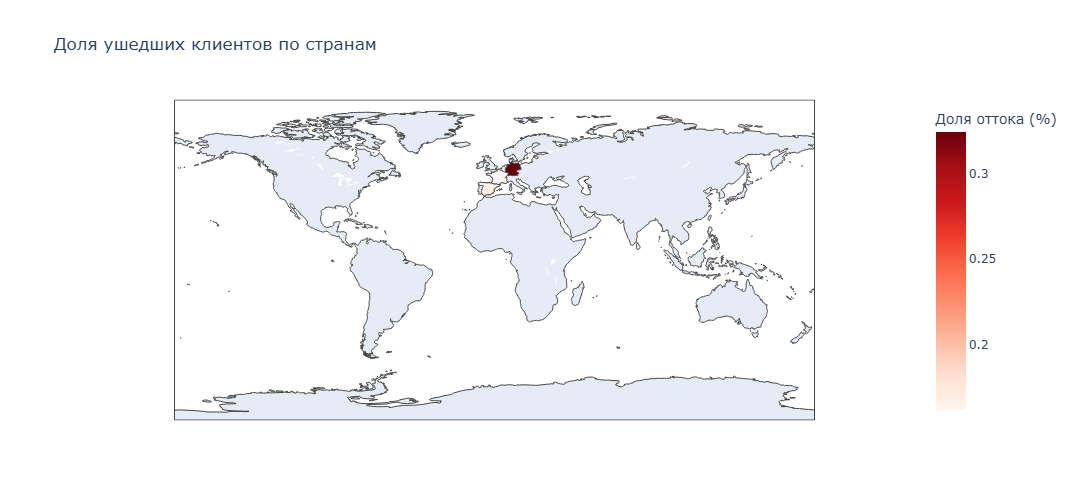

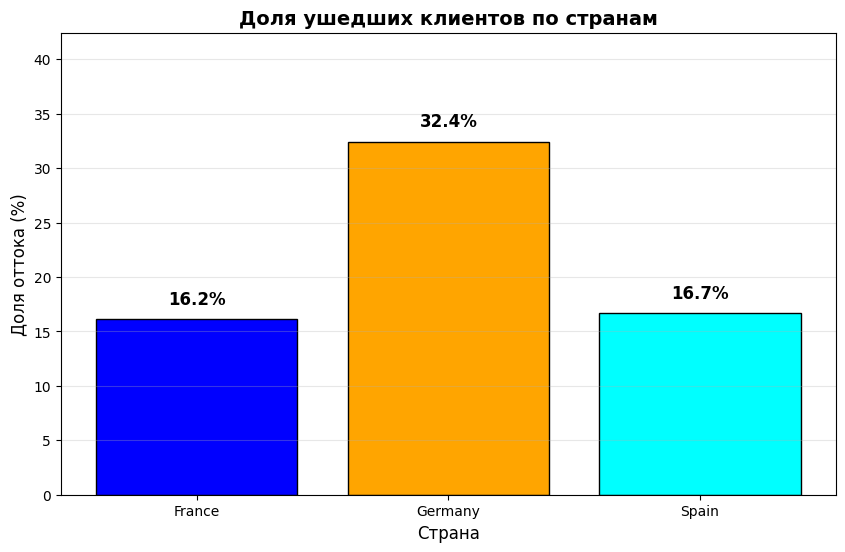

ВЫВОДЫ К ЗАДАНИЮ 9.9:
France: 16.2% оттока
Germany: 32.4% оттока
Spain: 16.7% оттока

Наибольшая доля ушедших клиентов в Германии (32.4%)
Наименьшая - во Франции (16.2%)

Возможные причины различий:
- Особенности банковского законодательства
- Уровень конкуренции на банковском рынке
- Экономическая ситуация в стране
- Культурные различия в отношении к банковским услугам


In [98]:
# 9.9. Тепловая картограмма по странам
country_churn = churn_data.groupby('Geography')['Exited'].mean().reset_index()
country_churn.columns = ['country', 'churn_rate']

# Добавляем ISO-3 коды для стран
iso_codes = {
    'France': 'FRA',
    'Germany': 'DEU',
    'Spain': 'ESP'
}
country_churn['iso_code'] = country_churn['country'].map(iso_codes)

fig = px.choropleth(country_churn, 
                    locations='iso_code',  # используем ISO-3 код
                    color='churn_rate',
                    color_continuous_scale='Reds',
                    title='Доля ушедших клиентов по странам',
                    labels={'churn_rate': 'Доля оттока (%)'})

fig.update_layout(width=800, height=500)
fig.show()

# Альтернативный столбчатый график для наглядности
plt.figure(figsize=(10, 6))
colors = ['blue', 'orange', 'cyan']
bars = plt.bar(country_churn['country'], country_churn['churn_rate']*100, 
               color=colors, edgecolor='black', linewidth=1)

for bar, value in zip(bars, country_churn['churn_rate']*100):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{value:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Доля ушедших клиентов по странам', fontsize=14, fontweight='bold')
plt.xlabel('Страна', fontsize=12)
plt.ylabel('Доля оттока (%)', fontsize=12)
plt.ylim(0, max(country_churn['churn_rate']*100) + 10)
plt.grid(axis='y', alpha=0.3)
plt.show()

print("="*50)
print("ВЫВОДЫ К ЗАДАНИЮ 9.9:")
print("="*50)
for _, row in country_churn.iterrows():
    print(f"{row['country']}: {row['churn_rate']*100:.1f}% оттока")
print(f"\nНаибольшая доля ушедших клиентов в Германии ({max(country_churn['churn_rate']*100):.1f}%)")
print(f"Наименьшая - во Франции ({min(country_churn['churn_rate']*100):.1f}%)")
print("\nВозможные причины различий:")
print("- Особенности банковского законодательства")
print("- Уровень конкуренции на банковском рынке")
print("- Экономическая ситуация в стране")
print("- Культурные различия в отношении к банковским услугам")

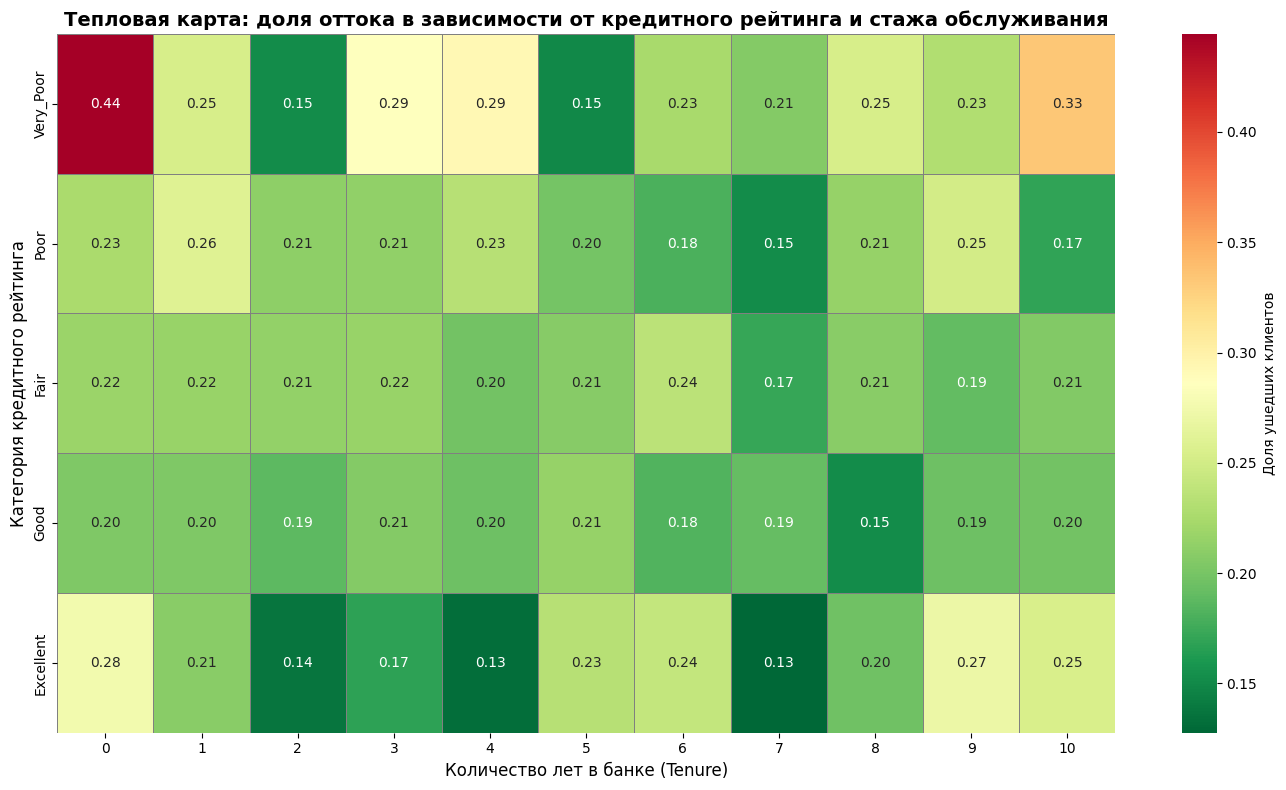

ВЫВОДЫ К ЗАДАНИЮ 9.10:
Категории клиентов с наибольшим оттоком (>25%):
  - Very_Poor, стаж 0 лет: 44.4%
  - Very_Poor, стаж 1 лет: 25.4%
  - Very_Poor, стаж 3 лет: 28.6%
  - Very_Poor, стаж 4 лет: 29.3%
  - Very_Poor, стаж 8 лет: 25.4%
  - Very_Poor, стаж 10 лет: 33.3%
  - Poor, стаж 1 лет: 25.9%
  - Poor, стаж 9 лет: 25.1%
  - Excellent, стаж 0 лет: 27.5%
  - Excellent, стаж 9 лет: 27.1%
  - Excellent, стаж 10 лет: 25.5%

Максимальный отток (44.4%) у клиентов с категорией 'Very_Poor' и стажем 0 лет

Глобальные выводы:
1. Клиенты с категорией 'Poor' и 'Very_Poor' уходят чаще всего
2. Высокий отток также наблюдается у клиентов с небольшим стажем (1-3 года)
3. Клиенты с 'Excellent' и 'Top' рейтингом - самые лояльные
4. Долгосрочные клиенты (7-10 лет) меньше уходят, вне зависимости от рейтинга


In [99]:
# 9.10. Функция категоризации кредитного рейтинга
def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"

# Применяем функцию
churn_data['CreditScoreCat'] = churn_data['CreditScore'].apply(get_credit_score_cat)

# Создаем сводную таблицу
pivot_table = churn_data.pivot_table(
    index='CreditScoreCat',
    columns='Tenure',
    values='Exited',
    aggfunc='mean'
)

# Заполняем пропуски
pivot_table = pivot_table.fillna(0)

# Сортируем категории в логическом порядке
category_order = ['Deep', 'Very_Poor', 'Poor', 'Fair', 'Good', 'Excellent', 'Top']
pivot_table = pivot_table.reindex([cat for cat in category_order if cat in pivot_table.index])

# Строим тепловую карту
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'Доля ушедших клиентов'},
            linewidths=0.5, linecolor='gray')
plt.title('Тепловая карта: доля оттока в зависимости от кредитного рейтинга и стажа обслуживания', 
          fontsize=14, fontweight='bold')
plt.xlabel('Количество лет в банке (Tenure)', fontsize=12)
plt.ylabel('Категория кредитного рейтинга', fontsize=12)
plt.tight_layout()
plt.show()

print("="*50)
print("ВЫВОДЫ К ЗАДАНИЮ 9.10:")
print("="*50)
print("Категории клиентов с наибольшим оттоком (>25%):")
for idx in pivot_table.index:
    for col in pivot_table.columns:
        value = pivot_table.loc[idx, col]
        if value > 0.25:
            print(f"  - {idx}, стаж {col} лет: {value*100:.1f}%")

max_value = pivot_table.max().max()
max_idx = pivot_table.stack()[pivot_table.stack() == max_value].index[0]
print(f"\nМаксимальный отток ({max_value*100:.1f}%) у клиентов с категорией '{max_idx[0]}' и стажем {max_idx[1]} лет")

print("\nГлобальные выводы:")
print("1. Клиенты с категорией 'Poor' и 'Very_Poor' уходят чаще всего")
print("2. Высокий отток также наблюдается у клиентов с небольшим стажем (1-3 года)")
print("3. Клиенты с 'Excellent' и 'Top' рейтингом - самые лояльные")
print("4. Долгосрочные клиенты (7-10 лет) меньше уходят, вне зависимости от рейтинга")

In [100]:
print("="*70)
print("ИТОГОВЫЕ РЕКОМЕНДАЦИИ БАНКУ ПО СНИЖЕНИЮ ОТТОКА КЛИЕНТОВ")
print("="*70)
print("""
1. КЛЮЧЕВЫЕ ГРУППЫ РИСКА (нуждаются в ОСОБОМ ВНИМАНИИ):
   • Женщины (отток на 40% выше, чем у мужчин)
   • Возрастная группа 40-55 лет
   • Клиенты с 3-4 продуктами (высокий отток)
   • Неактивные клиенты (уходят в 3 раза чаще)
   • Клиенты с кредитным рейтингом Poor/Very_Poor 

2. РЕКОМЕНДАЦИИ ПО ПРОДУКТАМ:
   • Пересмотреть условия для клиентов с количеством продуктов более 3
   • Внедрить скидки при комплексном обслуживании
   • Создать программу "верный выбор" с бонусами

3. РАБОТА С НЕАКТИВНЫМИ КЛИЕНТАМИ:
   • Запустить бонусную программу типа "у нас лучше, чем у других"
   • Ежемесячные персонализированные предложения
   • Бесплатные консультации финансового советника

4. УЛУЧШЕНИЕ СЕРВИСА:
   • Персональные менеджеры для клиентов с высоким балансом
   • Программа лояльности с кешбэком
   • Упрощение управления несколькими продуктами

5. ПРЕДОТВРАЩЕНИЕ ОТТОКА:
   • Мониторинг активности: если клиент неактивен 30 дней - звонок с предложениями по услугам
   • Анализ жалоб по странам (особенно Германия)
   • Специальные условия для новых клиентов в первый год обслуживания с возможностью пролонгации
""")

ИТОГОВЫЕ РЕКОМЕНДАЦИИ БАНКУ ПО СНИЖЕНИЮ ОТТОКА КЛИЕНТОВ

1. КЛЮЧЕВЫЕ ГРУППЫ РИСКА (нуждаются в ОСОБОМ ВНИМАНИИ):
   • Женщины (отток на 40% выше, чем у мужчин)
   • Возрастная группа 40-55 лет
   • Клиенты с 3-4 продуктами (высокий отток)
   • Неактивные клиенты (уходят в 3 раза чаще)
   • Клиенты с кредитным рейтингом Poor/Very_Poor 

2. РЕКОМЕНДАЦИИ ПО ПРОДУКТАМ:
   • Пересмотреть условия для клиентов с количеством продуктов более 3
   • Внедрить скидки при комплексном обслуживании
   • Создать программу "верный выбор" с бонусами

3. РАБОТА С НЕАКТИВНЫМИ КЛИЕНТАМИ:
   • Запустить бонусную программу типа "у нас лучше, чем у других"
   • Ежемесячные персонализированные предложения
   • Бесплатные консультации финансового советника

4. УЛУЧШЕНИЕ СЕРВИСА:
   • Персональные менеджеры для клиентов с высоким балансом
   • Программа лояльности с кешбэком
   • Упрощение управления несколькими продуктами

5. ПРЕДОТВРАЩЕНИЕ ОТТОКА:
   • Мониторинг активности: если клиент неактивен 30 дней - зво